<a href="https://colab.research.google.com/github/PratyushKattel/AI_project/blob/main/feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls

sample_data


In [ ]:
!kaggle datasets download -d vafaeii/kth-action-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/vafaeii/kth-action-recognition-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 1.07G/1.07G [00:57<00:00, 20.1MB/s]



In [ ]:
!unzip -q kth-action-recognition-dataset.zip -d ./kth_dataset && rm kth-action-recognition-dataset.zip

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
PATH = "kth_dataset"

final_path = os.path.join(os.getcwd())

os.chdir(final_path)

print(os.listdir())

['.config', 'kth_dataset', 'sample_data']


In [ ]:

os.chdir("kth_dataset")

In [ ]:
print(os.listdir())

['00sequences.txt', 'boxing', 'handclapping', 'walking', 'handwaving', 'running', 'jogging']


In [ ]:
from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
!ls

00sequences.txt  boxing  handclapping  handwaving  jogging  running  walking


In [ ]:
DATASET_PATH = "."

len of frames are 378
shape of single frame is (120, 160)


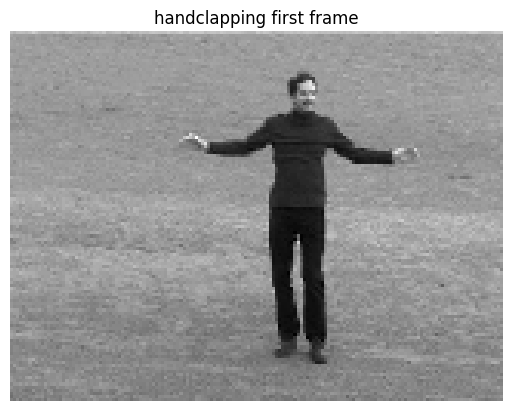

In [ ]:
import cv2
import matplotlib.pyplot as plt

# VIDEO_PATH = "boxing/person01_boxing_d1_uncomp.avi"
ACTION = "handclapping"

VIDEO_PATH = f"{ACTION}/person01_handclapping_d1_uncomp.avi"

capture = cv2.VideoCapture(VIDEO_PATH)

frames = []

while True:
  success,frame = capture.read()
  if not success:
    break

  frame = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
  frames.append(frame)

capture.release()

print(f"len of frames are {len(frames)}")

print(f"shape of single frame is {frames[0].shape}")

plt.imshow(frames[0],cmap="gray")
plt.title(f"{ACTION} first frame")
plt.axis("off")
plt.show()

In [ ]:
frames[0].shape

(120, 160)

### Implement HOG

In [ ]:
def compute_gradients(image):
  image = image.astype(float)

  gx = np.zeros(image.shape)
  gy = np.zeros(image.shape)

  #gx = I(x+1,y) -I(x-1,y)
  gx[:,1:-1] = (image[:,2:]-image[:,:-2]) / 2

  #gy = I(x,y+1) - I(x,y-1)
  gy[1:-1,:] = (image[2:,:]-image[:-2,:]) / 2

  g = np.sqrt(gx**2 + gy**2)
  orientation = np.rad2deg(np.arctan2(gy,gx))

  orientation[orientation < 0] += 180

  return g,orientation

In [ ]:
magnitude,orientation = compute_gradients(frames[0])

print(magnitude.shape,orientation.shape)

print(f"min magnitude is {magnitude.min()} and max magnitude is {magnitude.max()}")
print(f"min orientation is {orientation.min()} and max orientation is {orientation.max()}")

(120, 160) (120, 160)
min magnitude is 0.0 and max magnitude is 101.11874208078342
min orientation is 0.0 and max orientation is 180.0


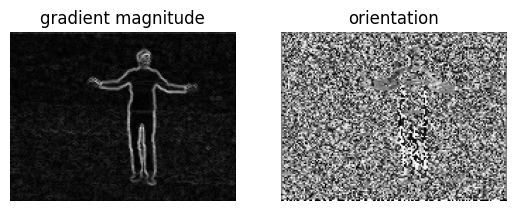

In [ ]:
fig,axes = plt.subplots(1,2)

axes[0].imshow(magnitude,cmap="gray")
axes[0].set_title("gradient magnitude")
axes[0].axis("off")

axes[1].imshow(orientation,cmap="gray")
axes[1].set_title("orientation")
axes[1].axis("off")

plt.show()

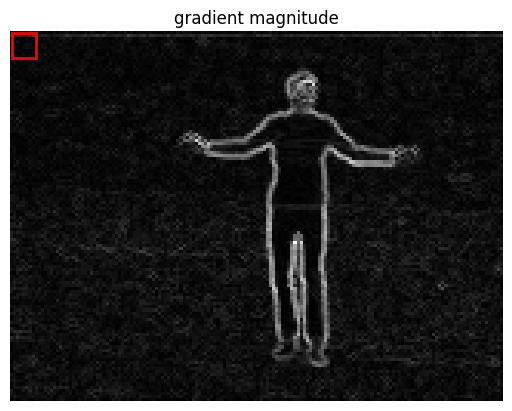

In [ ]:
from matplotlib.patches import Rectangle

plt.imshow(magnitude, cmap="gray")
rect = Rectangle((0, 0),8,8,fill=False,edgecolor="red",linewidth=2)
plt.gca().add_patch(rect)
plt.title("gradient magnitude")
plt.axis("off")
plt.show()

In [ ]:
def create_cell_histogram(magnitude,orientation,cell_size=8,bins=9):
    h,w=magnitude.shape

    cells_x=w//cell_size
    cells_y=h//cell_size

    hist=np.zeros((cells_y,cells_x,bins))

    bin_width=180/bins

    for i in range(cells_y):
        for j in range(cells_x):
            mag_cell=magnitude[
                i*cell_size:(i+1)*cell_size,
                j*cell_size:(j+1)*cell_size
            ]

            ori_cell=orientation[
                i*cell_size:(i+1)*cell_size,
                j*cell_size:(j+1)*cell_size
            ]


            for x in range(cell_size):
                for y in range(cell_size):
                    angle=ori_cell[x,y]

                    b=int(angle//bin_width)

                    if b==bins:
                        b=0
                    hist[i,j,b]+=mag_cell[x,y]
    return hist

In [ ]:
cell_histogram = create_cell_histogram(magnitude,orientation)

In [ ]:
print(cell_histogram.shape)

(15, 20, 9)


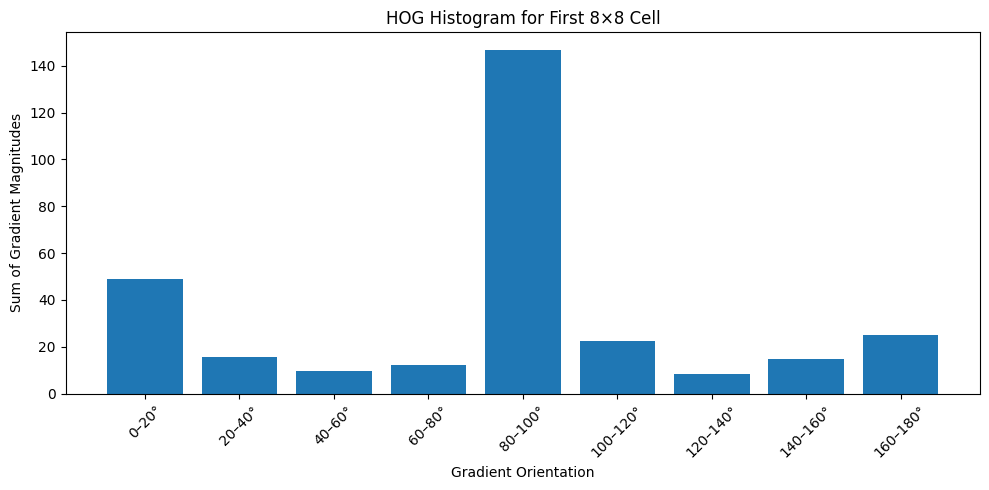

In [ ]:
cell_mag = magnitude[0:8, 0:8]
cell_ori = orientation[0:8, 0:8]

bins = 9
bin_width = 180 / bins

hist = np.zeros(bins)

for i in range(8):
    for j in range(8):

        angle = cell_ori[i, j]
        mag = cell_mag[i, j]

        b = int(angle // bin_width)

        if b == bins:
            b = 0

        hist[b] += mag

bin_labels = [
    "0–20°",
    "20–40°",
    "40–60°",
    "60–80°",
    "80–100°",
    "100–120°",
    "120–140°",
    "140–160°",
    "160–180°"
]

plt.figure(figsize=(10, 5))
plt.bar(bin_labels, hist)
plt.xlabel("Gradient Orientation")
plt.ylabel("Sum of Gradient Magnitudes")
plt.title("HOG Histogram for First 8×8 Cell")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(np.round(cell_histogram[0, 0], 3))

[ 48.845  15.793   9.736  12.359 146.934  22.461   8.529  14.625  25.102]


In [ ]:
def normalize_blocks(hist):
  eps = 1e-5

  h,w,bins=hist.shape

  features = []

  for i in range(h-1):
    for j in range(w-1):
      block = hist[i:i+2,j:j+2,:]
      vector = block.flatten()

      norm = np.sqrt(np.sum(vector**2) + eps)

      vector = vector/norm
      features.extend(vector)

  return np.array(features)

In [ ]:
hog_feature=normalize_blocks(cell_histogram)

print("Hog Feature Length:",hog_feature.shape)

Hog Feature Length: (9576,)


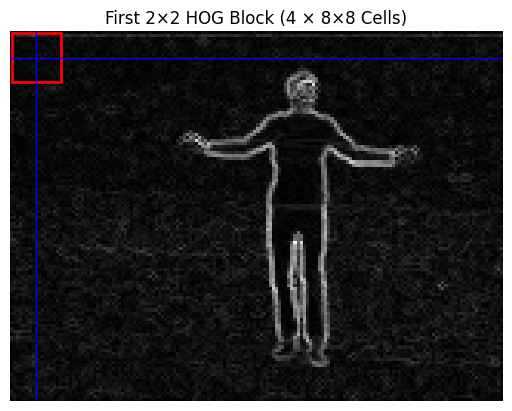

In [ ]:
from matplotlib.patches import Rectangle

plt.imshow(magnitude, cmap="gray")

# First 2×2 HOG block = 16×16 pixels
rect = Rectangle(
    (0, 0),
    16,
    16,
    fill=False,
    edgecolor="red",
    linewidth=2
)

plt.gca().add_patch(rect)

# Draw the 8×8 cell boundaries
plt.axvline(8, color="blue", linewidth=1)
plt.axhline(8, color="blue", linewidth=1)

plt.title("First 2×2 HOG Block (4 × 8×8 Cells)")
plt.axis("off")

plt.show()

In [ ]:
def extract_video_hog(frames):
  features = []

  for idx,frame in enumerate(frames):
    magnitude,orientation = compute_gradients(frame)
    hist = create_cell_histogram(magnitude,orientation)
    feature = normalize_blocks(hist)

    features.append(feature)

    if idx % 50 == 0:
      print("Processed Frame:",idx)

  features = np.array(features)
  print(f"frame feature matrix : {features.shape}")

  video_feature = np.mean(features,axis=0)
  print(f"video feature {video_feature.shape}")

  return video_feature

## Now Optical Flow From Scratch


In [ ]:
def compute_optical_flow_gradients(frame1,frame2):
  frame1 = frame1.astype(float)
  frame2 = frame2.astype(float)

  Ix = np.zeros_like(frame1)
  Iy = np.zeros_like(frame1)

  Ix[:,1:-1] = (frame1[:,2:]-frame1[:,:-2]) / 2
  Iy[1:-1,:] = (frame1[2:,:]-frame1[:-2,:]) / 2

  It = frame2-frame1

  return Ix,Iy,It

In [ ]:
frame1,frame2 = frames[0],frames[20]
Ix,Iy,It = compute_optical_flow_gradients(frame1,frame2)
print(Ix.shape,Iy.shape,It.shape)

(120, 160) (120, 160) (120, 160)


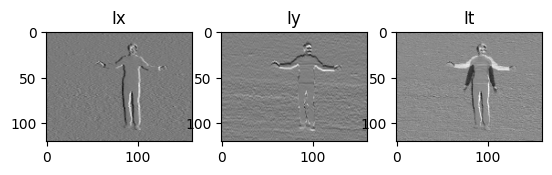

In [ ]:
fig,axes = plt.subplots(1,3)

axes[0].set_title("Ix")
axes[0].imshow(Ix,cmap="gray")

axes[1].set_title("Iy")
axes[1].imshow(Iy,cmap="gray")

axes[2].set_title("It")
axes[2].imshow(It,cmap="gray")

In [ ]:
def lucas_kanade(Ix, Iy, It, windows_size=5):
    h, w = Ix.shape

    u = np.zeros_like(Ix)
    v = np.zeros_like(Ix)

    offset = windows_size // 2

    for y in range(offset, h-offset):
        for x in range(offset, w-offset):

            Ix_window = Ix[
                y-offset:y+offset+1,
                x-offset:x+offset+1
            ].flatten()

            Iy_window = Iy[
                y-offset:y+offset+1,
                x-offset:x+offset+1
            ].flatten()

            It_window = It[
                y-offset:y+offset+1,
                x-offset:x+offset+1
            ].flatten()

            A = np.vstack((Ix_window, Iy_window)).T
            B = -It_window

            try:
                velocity = np.linalg.inv(A.T @ A) @ A.T @ B

                u[y, x] = velocity[0]
                v[y, x] = velocity[1]

            except:
                pass

    return u, v

In [ ]:
u,v=lucas_kanade(Ix,Iy,It)

print(u.shape,v.shape)

(120, 160) (120, 160)


<Figure size 1000x400 with 0 Axes>

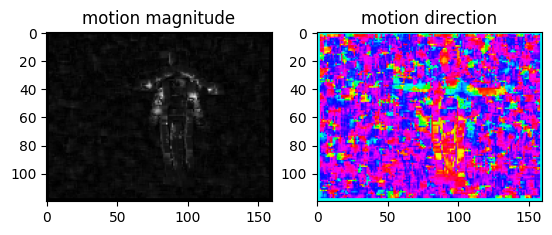

In [ ]:
flow_magnitude = np.sqrt(u**2 + v**2)
flow_angle=np.arctan2(v,u)

plt.figure(figsize=(10,4))
figure,axes = plt.subplots(1,2)

axes[0].imshow(flow_magnitude,cmap="gray")
axes[0].set_title("motion magnitude")

axes[1].imshow(flow_angle,cmap="hsv")
axes[1].set_title("motion direction")

plt.show()

In [ ]:
def flow_feature(u,v):
    feature=np.concatenate([u.flatten(),v.flatten()])
    return feature

In [ ]:
flow_vec=flow_feature(u,v)

print("optical flow vector:",flow_vec.shape)

optical flow vector: (38400,)


In [ ]:
def extract_video_flow(frames):
    features=[]

    for i in range(len(frames)-1):
        Ix,Iy,It = compute_optical_flow_gradients(frames[i],frames[i+1])

        u,v = lucas_kanade(Ix,Iy,It)
        feat = flow_feature(u,v)

        features.append(feat)

        if i%50==0:
            print(f"processed pair : {i}")

    features=np.array(features)
    print("flow matrix: ",features.shape)
    video_flow=np.mean(features,axis=0)
    print(f"video flow feature:{video_flow.shape}")

    return video_flow

In [ ]:
flow_vec = flow_feature(u,v)

print(type(flow_vec))
print(flow_vec.shape)

<class 'numpy.ndarray'>
(38400,)


In [ ]:
#concatenate so that feature = [HOG,Flow]
final_feature = np.concatenate(
    [
        hog_feature,
        flow_vec
    ]
)

print(final_feature.shape)

(47976,)


In [ ]:
classes = ["boxing","handclapping","handwaving","jogging","running","walking"]

label_map = {
    "boxing":0,
    "handclapping":1,
    "handwaving":2,
    "jogging":3,
    "running":4,
    "walking":5
}


print(label_map)

{'boxing': 0, 'handclapping': 1, 'handwaving': 2, 'jogging': 3, 'running': 4, 'walking': 5}


In [ ]:
def read_video(path):
    cap=cv2.VideoCapture(path)

    frames=[]
    while True:
        success,frame=cap.read()

        if not success:
            break

        frame=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
        frames.append(frame)

    cap.release()
    return frames

In [ ]:
video_path="boxing/person01_boxing_d1_uncomp.avi"

frames=read_video(video_path)

print(f"Number of frames: {len(frames)}")
print(f"Frame shape:{frames[0].shape}")

Number of frames: 360
Frame shape:(120, 160)


In [ ]:
#Video Feature Extractor

def extract_video_descriptor(frames):
  print("Extracting hog.....")

  hog_vector = extract_video_hog(frames)

  print("Extracting optical flow...")
  flow_vector = extract_video_flow(frames)

  print("now, just combiting bots")
  video_descriptor = np.concatenate([hog_vector,flow_vector])

  print(f"shape of final descriptor is {video_descriptor.shape}")
  return video_descriptor

In [ ]:
descriptor = extract_video_descriptor(frames)

Extracting hog.....
Processed Frame: 0
Processed Frame: 50
Processed Frame: 100
Processed Frame: 150
Processed Frame: 200
Processed Frame: 250
Processed Frame: 300
Processed Frame: 350
frame feature matrix : (360, 9576)
video feature (9576,)
Extracting optical flow...
processed pair : 0
processed pair : 50
processed pair : 100


KeyboardInterrupt: 

In [ ]:
#Extract features from all videos

In [ ]:
import glob

DATASET_PATH="."
X=[]
y=[]

for action in classes:
    folder=os.path.join(DATASET_PATH,action)
    videos=glob.glob(folder+"/*.avi")

    print("\nAction:",action)
    print("Videos:",len(videos))

    for video in videos:
        print("\nProcessing:",video)
        frames = read_video(video)

        descriptor=extract_video_descriptor(frames)
        X.append(descriptor)

        y.append(label_map[action])


Action: boxing
Videos: 100

Processing: ./boxing/person21_boxing_d2_uncomp.avi
Extracting hog.....
Processed Frame: 0
Processed Frame: 50
Processed Frame: 100
Processed Frame: 150
Processed Frame: 200
Processed Frame: 250
Processed Frame: 300
Processed Frame: 350
Processed Frame: 400
frame feature matrix : (408, 9576)
video feature (9576,)
Extracting optical flow...
processed pair : 0
processed pair : 50
processed pair : 100
processed pair : 150
processed pair : 200
processed pair : 250
processed pair : 300
processed pair : 350
processed pair : 400
flow matrix:  (407, 38400)
video flow feature:(38400,)
now, just combiting bots
shape of final descriptor is (47976,)

Processing: ./boxing/person03_boxing_d3_uncomp.avi
Extracting hog.....
Processed Frame: 0
Processed Frame: 50
Processed Frame: 100
Processed Frame: 150
Processed Frame: 200
Processed Frame: 250
Processed Frame: 300
Processed Frame: 350
Processed Frame: 400
frame feature matrix : (414, 9576)
video feature (9576,)
Extracting 

KeyboardInterrupt: 

In [ ]:
X = np.array(X)
y = np.array(y)
print(f"feature matrix is:{X.shape} and label shape is {y.shape}")

np.save(np.save("KTH_features.npy",X))
np.save("KTH_labels.npy",y)

In [ ]:
unique,count=np.unique(y,return_counts=True)

for u,c in zip(unique,count):
    print(classes[u],c)

## Implementing SVM

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y)

print("Training:",X_train.shape)
print("Testing:",X_test.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
from sklearn.svm import SVC

svm=SVC(kernel="rbf",C=10,gamma="scale")
svm.fit(X_train,y_train)

In [ ]:
y_pred=svm.predict(X_test)

print(y_pred[:20])

In [ ]:
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

print(cm)

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:


from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred,target_names=classes))


In [ ]:
import pickle

with open("hog_flow_svm.pkl","wb") as f:
    pickle.dump(svm,f)

with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)


## Deep Learning Models

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import copy

In [ ]:
NUM_FRAMES = 40
FRAME_SIZE = 64
NUM_CLASSES = 6
BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import torchvision.transforms as transforms

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=NUM_FRAMES, frame_size=FRAME_SIZE):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.frame_size = frame_size

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        frames = read_video(self.video_paths[idx])

        # Sample exactly num_frames evenly-spaced frames
        total = len(frames)
        if total >= self.num_frames:
            indices = np.linspace(0, total - 1, self.num_frames, dtype=int)
        else:
            indices = list(range(total))
            while len(indices) < self.num_frames:
                indices.append(total - 1)

        sampled = [frames[i] for i in indices]

        # Resize and normalize to [0, 1]
        resized = []
        for f in sampled:
            f = cv2.resize(f, (self.frame_size, self.frame_size))
            f = f.astype(np.float32) / 255.0
            resized.append(f)

        # Stack into (num_frames, H, W) then add channel dim -> (1, num_frames, H, W)
        video = np.stack(resized)
        video = torch.tensor(video).unsqueeze(0)  # (1, num_frames, 64, 64)
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return video, label

In [ ]:
# Collect all video paths and labels
all_paths = []
all_labels = []

for action in classes:
    folder = os.path.join(DATASET_PATH, action)
    vids = sorted(glob.glob(os.path.join(folder, "*.avi")))
    for v in vids:
        all_paths.append(v)
        all_labels.append(label_map[action])

print(f"Total videos: {len(all_paths)}")
print(f"Videos per class: {[all_labels.count(i) for i in range(NUM_CLASSES)]}")

Total videos: 599
Videos per class: [100, 99, 100, 100, 100, 100]


In [ ]:
import torchvision.transforms as transforms

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=NUM_FRAMES, frame_size=FRAME_SIZE):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.frame_size = frame_size

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        frames = read_video(self.video_paths[idx])

        # Sample exactly num_frames evenly-spaced frames
        total = len(frames)
        if total >= self.num_frames:
            indices = np.linspace(0, total - 1, self.num_frames, dtype=int)
        else:
            indices = list(range(total))
            while len(indices) < self.num_frames:
                indices.append(total - 1)

        sampled = [frames[i] for i in indices]

        # Resize and normalize to [0, 1]
        resized = []
        for f in sampled:
            f = cv2.resize(f, (self.frame_size, self.frame_size))
            f = f.astype(np.float32) / 255.0
            resized.append(f)

        # Stack into (num_frames, H, W) then add channel dim -> (1, num_frames, H, W)
        video = np.stack(resized)
        video = torch.tensor(video).unsqueeze(0)  # (1, num_frames, 64, 64) - Channel first
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return video, label

# Collect all video paths and labels
all_paths = []
all_labels = []

for action in classes:
    folder = os.path.join(DATASET_PATH, action)
    vids = sorted(glob.glob(os.path.join(folder, "*.avi")))
    for v in vids:
        all_paths.append(v)
        all_labels.append(label_map[action])

print(f"Total videos: {len(all_paths)}")
print(f"Videos per class: {[all_labels.count(i) for i in range(NUM_CLASSES)]}")

# Train/test split
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

train_dataset = VideoDataset(train_paths, train_labels)
test_dataset = VideoDataset(test_paths, test_labels)

def collate_fn(batch):
    videos = torch.stack([b[0] for b in batch]) # Changed torch.cat to torch.stack
    labels = torch.stack([b[1] for b in batch])
    return videos, labels

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_dataset)} videos, Test: {len(test_dataset)} videos")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Total videos: 599
Videos per class: [100, 99, 100, 100, 100, 100]
Train: 479 videos, Test: 120 videos
Train batches: 60, Test batches: 15


### CNN Baseline

In [ ]:
class VideoCNN(nn.Module):
    """CNN that processes each frame independently then averages predictions."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(4)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x: (B, 1, T, 64, 64)
        B, C, T, H, W = x.shape
        x = x.view(B * T, C, H, W)    # (B*T, 1, 64, 64)
        feat = self.features(x)         # (B*T, 128, 4, 4)
        feat = feat.view(feat.size(0), -1)  # (B*T, 2048)
        logits = self.classifier(feat)  # (B*T, 6)
        logits = logits.view(B, T, -1)  # (B, T, 6)
        return logits.mean(dim=1)       # (B, 6) - average over frames


cnn_model = VideoCNN().to(device)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"CNN model parameters: {total_params:,}")
print(cnn_model)

CNN model parameters: 618,758
VideoCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=4)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)


In [ ]:
def train_cnn(model, train_loader, test_loader, epochs=EPOCHS, lr=LR):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler()
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for batch_idx, (videos, labels) in enumerate(train_loader):
            videos, labels = videos.to(device), labels.to(device)

            optimizer.zero_grad()
            with autocast():
                outputs = model(videos)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * videos.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            if batch_idx % 5 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

        train_loss = running_loss / total
        train_acc = correct / total

        # Evaluate
        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for videos, labels in test_loader:
                videos, labels = videos.to(device), labels.to(device)
                outputs = model(videos)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * videos.size(0)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        t_loss = test_loss / test_total
        t_acc = test_correct / test_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(t_loss)
        history['test_acc'].append(t_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Test Loss: {t_loss:.4f} Acc: {t_acc:.4f}")

        if t_acc > best_acc:
            best_acc = t_acc
            best_model = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model)
    print(f"\nBest test accuracy: {best_acc:.4f}")
    return history

In [ ]:
def evaluate_model(model, test_loader, model_name="Model"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for videos, labels in test_loader:
            videos = videos.to(device)
            outputs = model(videos)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    print(f"\n{model_name} Test Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return acc

In [ ]:
# Train CNN
cnn_history = train_cnn(cnn_model, train_loader, test_loader)

/tmp/ipykernel_2012/1015529570.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_2012/1015529570.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Batch 0/60 | Loss: 1.7843
  Batch 5/60 | Loss: 1.8225
  Batch 10/60 | Loss: 1.8163
  Batch 15/60 | Loss: 1.7845
  Batch 20/60 | Loss: 1.8060
  Batch 25/60 | Loss: 1.8077
  Batch 30/60 | Loss: 1.7880
  Batch 35/60 | Loss: 1.7906
  Batch 40/60 | Loss: 1.7897
  Batch 45/60 | Loss: 1.8024
  Batch 50/60 | Loss: 1.7816
  Batch 55/60 | Loss: 1.7935
Epoch [1/20] Train Loss: 1.7943 Acc: 0.1670 | Test Loss: 1.7898 Acc: 0.1667
  Batch 0/60 | Loss: 1.7950
  Batch 5/60 | Loss: 1.7987
  Batch 10/60 | Loss: 1.7942
  Batch 15/60 | Loss: 1.7681
  Batch 20/60 | Loss: 1.7833
  Batch 25/60 | Loss: 1.8010
  Batch 30/60 | Loss: 1.7856
  Batch 35/60 | Loss: 1.7712
  Batch 40/60 | Loss: 1.7350
  Batch 45/60 | Loss: 1.7881
  Batch 50/60 | Loss: 1.7573
  Batch 55/60 | Loss: 1.7550
Epoch [2/20] Train Loss: 1.7806 Acc: 0.1670 | Test Loss: 1.7438 Acc: 0.1750
  Batch 0/60 | Loss: 1.7483
  Batch 5/60 | Loss: 1.7397
  Batch 10/60 | Loss: 1.6901
  Batch 15/60 | Loss: 1.6940
  Batch 20/60 | Loss: 1.6884
  Batch 25/60

/tmp/ipykernel_2012/1015529570.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Batch 35/60 | Loss: 1.0877
  Batch 40/60 | Loss: 1.1627
  Batch 45/60 | Loss: 1.1818
  Batch 50/60 | Loss: 0.9457
  Batch 55/60 | Loss: 1.1208
Epoch [7/20] Train Loss: 1.0737 Acc: 0.4363 | Test Loss: 1.0969 Acc: 0.4083
  Batch 0/60 | Loss: 1.2004
  Batch 5/60 | Loss: 0.9685
  Batch 10/60 | Loss: 1.2752
  Batch 15/60 | Loss: 0.7950
  Batch 20/60 | Loss: 1.2007
  Batch 25/60 | Loss: 1.0143
  Batch 30/60 | Loss: 0.9899
  Batch 35/60 | Loss: 0.9390
  Batch 40/60 | Loss: 1.3470
  Batch 45/60 | Loss: 1.1774
  Batch 50/60 | Loss: 1.0187
  Batch 55/60 | Loss: 1.1390
Epoch [8/20] Train Loss: 1.0598 Acc: 0.4154 | Test Loss: 1.0945 Acc: 0.4333
  Batch 0/60 | Loss: 0.7731
  Batch 5/60 | Loss: 0.9874
  Batch 10/60 | Loss: 1.0134
  Batch 15/60 | Loss: 1.1056
  Batch 20/60 | Loss: 1.0387
  Batch 25/60 | Loss: 1.3220
  Batch 30/60 | Loss: 1.0541
  Batch 35/60 | Loss: 0.8907
  Batch 40/60 | Loss: 1.2950
  Batch 45/60 | Loss: 0.9263
  Batch 50/60 | Loss: 1.0821
  Batch 55/60 | Loss: 1.0825
Epoch [9/20

In [ ]:
# Evaluate CNN
# cnn_acc = evaluate_model(cnn_model, test_loader, model_name="CNN Baseline")
torch.save(cnn_model.state_dict(), "video_cnn.pt")
print("CNN model saved to video_cnn.pt")

CNN model saved to video_cnn.pt


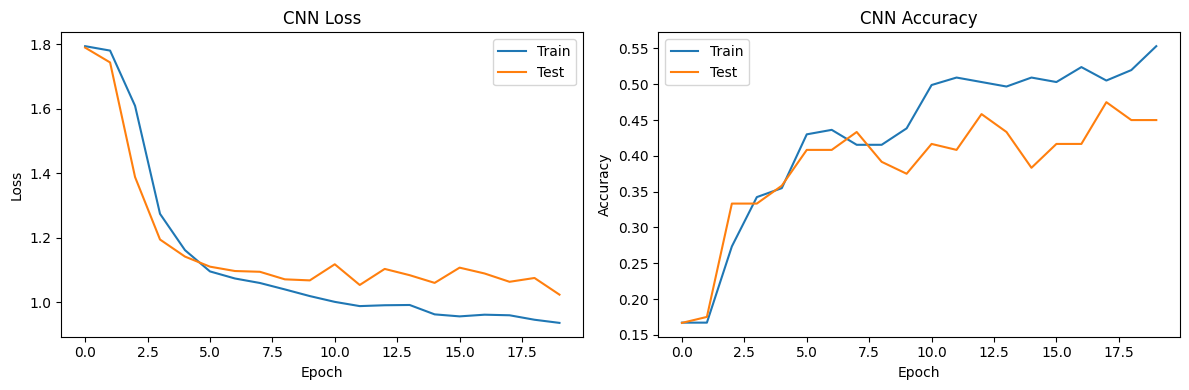

In [ ]:
# Plot CNN training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(cnn_history['train_loss'], label='Train')
ax1.plot(cnn_history['test_loss'], label='Test')
ax1.set_title('CNN Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(cnn_history['train_acc'], label='Train')
ax2.plot(cnn_history['test_acc'], label='Test')
ax2.set_title('CNN Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

### CNN + LSTM

In [ ]:
class VideoCNNLSTM(nn.Module):
    """CNN extracts per-frame features, LSTM captures temporal dynamics."""
    def __init__(self, num_classes=NUM_CLASSES, hidden_size=128, num_layers=2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(4)
        )
        self.cnn_fc = nn.Linear(128 * 4 * 4, hidden_size)
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (B, 1, T, 64, 64)
        B, C, T, H, W = x.shape
        x = x.view(B * T, C, H, W)       # (B*T, 1, 64, 64)
        feat = self.cnn(x)                # (B*T, 128, 4, 4)
        feat = feat.view(feat.size(0), -1) # (B*T, 2048)
        feat = torch.relu(self.cnn_fc(feat))  # (B*T, hidden)
        feat = feat.view(B, T, -1)         # (B, T, hidden)
        lstm_out, (h_n, c_n) = self.lstm(feat)  # lstm_out: (B, T, hidden)
        last = lstm_out[:, -1, :]          # (B, hidden)
        return self.classifier(last)       # (B, num_classes)


lstm_model = VideoCNNLSTM().to(device)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"CNN+LSTM model parameters: {total_params:,}")
print(lstm_model)

CNN+LSTM model parameters: 619,910
VideoCNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=4)
  )
  (cnn_fc): Linear(in_features=2048, out_features=128, bias=True)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Linear(in_features=128, out_features=6, bias=True)
)


In [ ]:
def train_lstm(model, train_loader, test_loader, epochs=EPOCHS, lr=LR):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler()
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for batch_idx, (videos, labels) in enumerate(train_loader):
            videos, labels = videos.to(device), labels.to(device)

            optimizer.zero_grad()
            with autocast():
                outputs = model(videos)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * videos.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            if batch_idx % 5 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

        train_loss = running_loss / total
        train_acc = correct / total

        # Evaluate
        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for videos, labels in test_loader:
                videos, labels = videos.to(device), labels.to(device)
                outputs = model(videos)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * videos.size(0)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        t_loss = test_loss / test_total
        t_acc = test_correct / test_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(t_loss)
        history['test_acc'].append(t_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Test Loss: {t_loss:.4f} Acc: {t_acc:.4f}")

        if t_acc > best_acc:
            best_acc = t_acc
            best_model = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model)
    print(f"\nBest test accuracy: {best_acc:.4f}")
    return history

In [ ]:
# Train CNN+LSTM
lstm_history = train_lstm(lstm_model, train_loader, test_loader)

/tmp/ipykernel_2012/210410185.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_2012/210410185.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Batch 0/60 | Loss: 1.7986
  Batch 5/60 | Loss: 1.7957
  Batch 10/60 | Loss: 1.7894
  Batch 15/60 | Loss: 1.8083
  Batch 20/60 | Loss: 1.7954
  Batch 25/60 | Loss: 1.7924
  Batch 30/60 | Loss: 1.7853
  Batch 35/60 | Loss: 1.7958
  Batch 40/60 | Loss: 1.7927
  Batch 45/60 | Loss: 1.7952
  Batch 50/60 | Loss: 1.7937
  Batch 55/60 | Loss: 1.7914
Epoch [1/20] Train Loss: 1.7934 Acc: 0.1691 | Test Loss: 1.7919 Acc: 0.1667
  Batch 0/60 | Loss: 1.7972
  Batch 5/60 | Loss: 1.7941
  Batch 10/60 | Loss: 1.7990
  Batch 15/60 | Loss: 1.8033
  Batch 20/60 | Loss: 1.7825
  Batch 25/60 | Loss: 1.7855
  Batch 30/60 | Loss: 1.7942
  Batch 35/60 | Loss: 1.7871
  Batch 40/60 | Loss: 1.7871
  Batch 45/60 | Loss: 1.7928
  Batch 50/60 | Loss: 1.7888
  Batch 55/60 | Loss: 1.7881
Epoch [2/20] Train Loss: 1.7920 Acc: 0.1670 | Test Loss: 1.7915 Acc: 0.1667
  Batch 0/60 | Loss: 1.8025
  Batch 5/60 | Loss: 1.7981
  Batch 10/60 | Loss: 1.7900
  Batch 15/60 | Loss: 1.7917
  Batch 20/60 | Loss: 1.7764
  Batch 25/60

In [ ]:
# Evaluate CNN+LSTM
# lstm_acc = evaluate_model(lstm_model, test_loader, model_name="CNN+LSTM")
torch.save(lstm_model.state_dict(), "video_cnn_lstm.pt")
print("CNN+LSTM model saved to video_cnn_lstm.pt")

CNN+LSTM model saved to video_cnn_lstm.pt


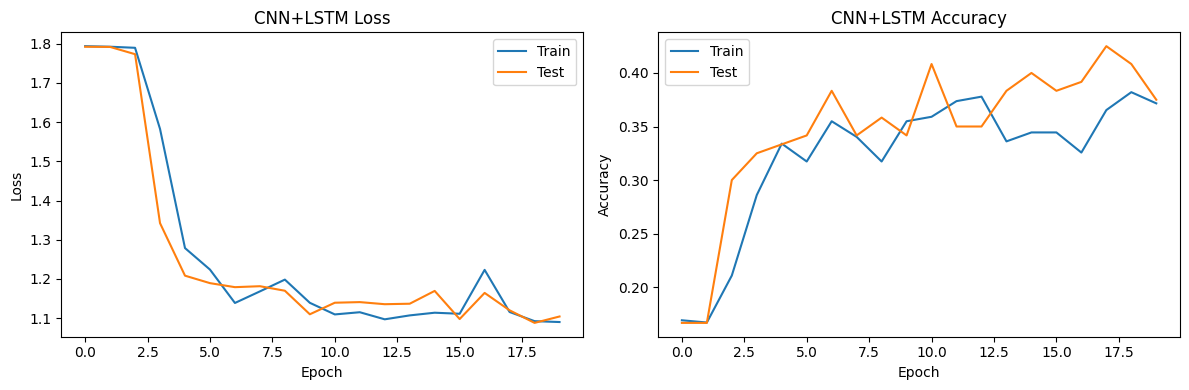

In [ ]:
# Plot CNN+LSTM training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(lstm_history['train_loss'], label='Train')
ax1.plot(lstm_history['test_loss'], label='Test')
ax1.set_title('CNN+LSTM Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(lstm_history['train_acc'], label='Train')
ax2.plot(lstm_history['test_acc'], label='Test')
ax2.set_title('CNN+LSTM Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

Models loaded successfully!

Video: boxing/person01_boxing_d1_uncomp.avi
CNN Prediction:      boxing (confidence: 0.1803)
CNN+LSTM Prediction: handclapping (confidence: 0.3762)


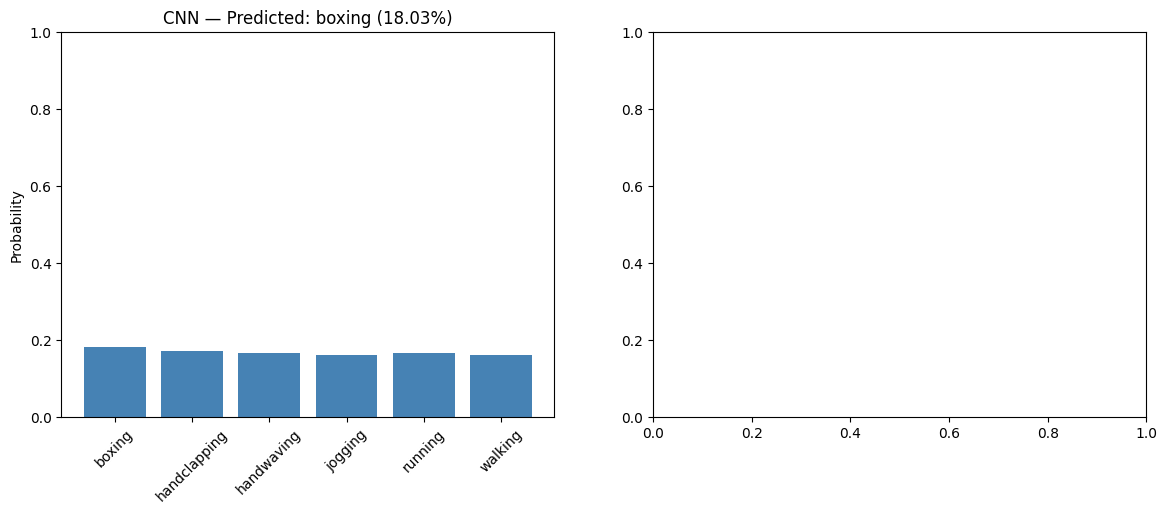

In [ ]:
def predict_video(model, video_path, model_type="cnn", device=device):

    frames = read_video(video_path)

    #
    total = len(frames)
    if total >= NUM_FRAMES:
        indices = np.linspace(0, total - 1, NUM_FRAMES, dtype=int)
    else:
        indices = list(range(total))
        while len(indices) < NUM_FRAMES:
            indices.append(total - 1)

    sampled = [frames[i] for i in indices]

    # Resize and normalize
    resized = []
    for f in sampled:
        f = cv2.resize(f, (FRAME_SIZE, FRAME_SIZE))
        f = f.astype(np.float32) / 255.0
        resized.append(f)

    # Tensor: (1, 1, T, H, W)
    video = np.stack(resized)
    video = torch.tensor(video).unsqueeze(0).unsqueeze(0)  # (1, 1, 40, 64, 64)
    video = video.to(device)

    model.eval()
    with torch.no_grad():
        output = model(video)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
        # Fix: use max() for value and argmax() for index in NumPy
        conf = probs.max()
        pred_idx = probs.argmax()

    return classes[pred_idx], conf.item(), probs


# --- Load saved models ---
# CNN
cnn_model = VideoCNN().to(device)
cnn_model.load_state_dict(torch.load("video_cnn.pt", map_location=device))
cnn_model.eval()

# CNN+LSTM
lstm_model = VideoCNNLSTM().to(device)
lstm_model.load_state_dict(torch.load("video_cnn_lstm.pt", map_location=device))
lstm_model.eval()

print("Models loaded successfully!")


# --- Run on a single video ---
test_video = "boxing/person01_boxing_d1_uncomp.avi"

pred_cnn, conf_cnn, probs_cnn = predict_video(cnn_model, test_video, "cnn")
pred_lstm, conf_lstm, probs_lstm = predict_video(lstm_model, test_video, "cnn_lstm")

print(f"\nVideo: {test_video}")
print(f"CNN Prediction:      {pred_cnn} (confidence: {conf_cnn:.4f})")
print(f"CNN+LSTM Prediction: {pred_lstm} (confidence: {conf_lstm:.4f})")


# --- Visualize predictions ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(classes, probs_cnn, color='steelblue')
ax1.set_title(f"CNN — Predicted: {pred_cnn} ({conf_cnn:.2%})")
ax1.set_ylabel("Probability")
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)

### Visualizing Intermediate Feature Maps
This section demonstrates how the CNN extracts spatial features from video frames. We will hook into the model to capture the output of the convolutional layers.

Visualizing Layer 1 (Conv2d 1->32)...


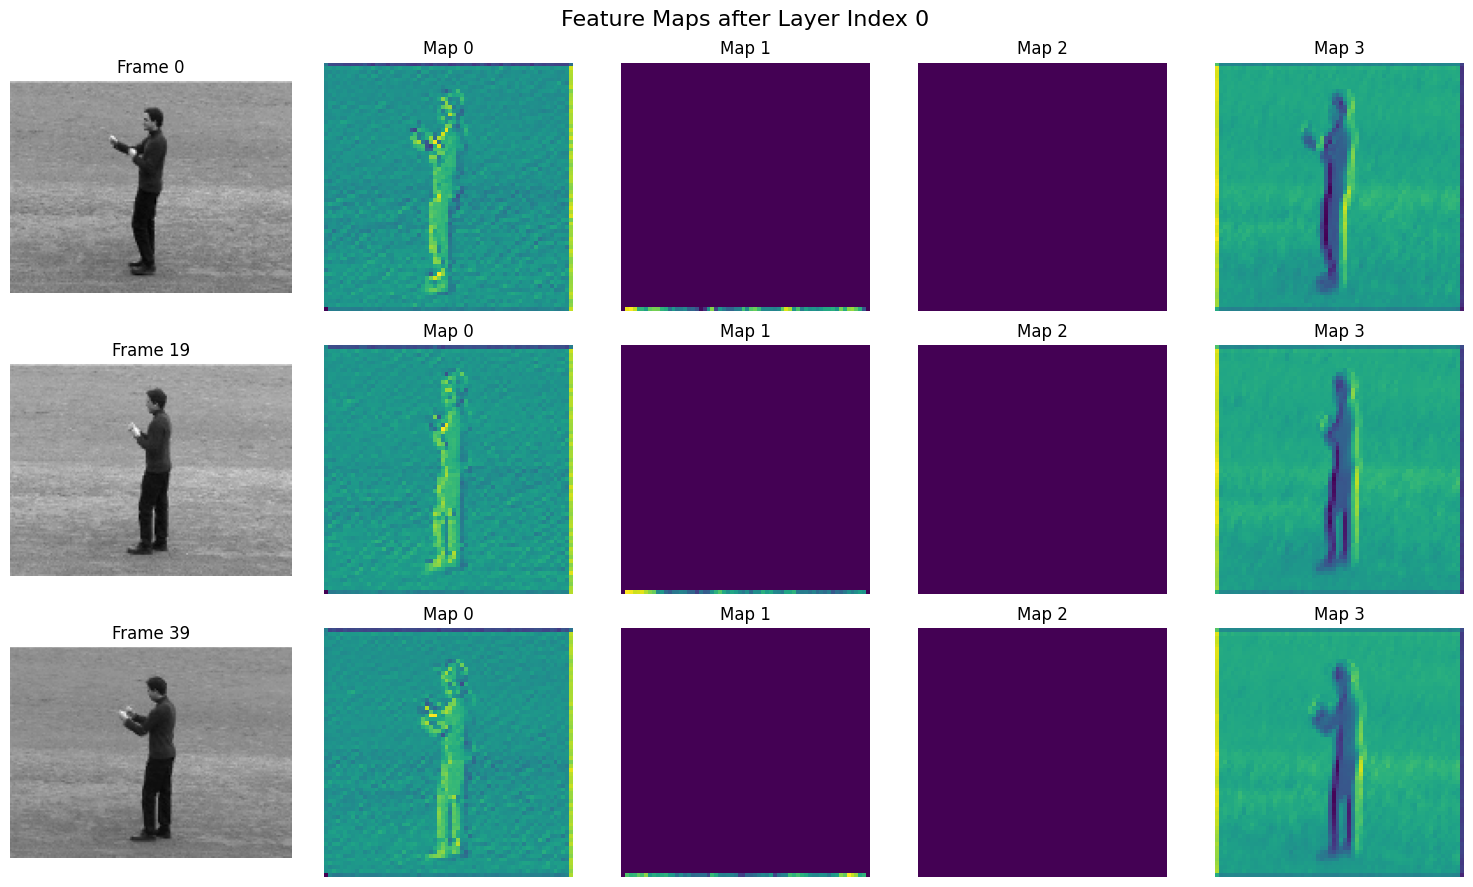

Visualizing Layer 2 (After second Conv block)...


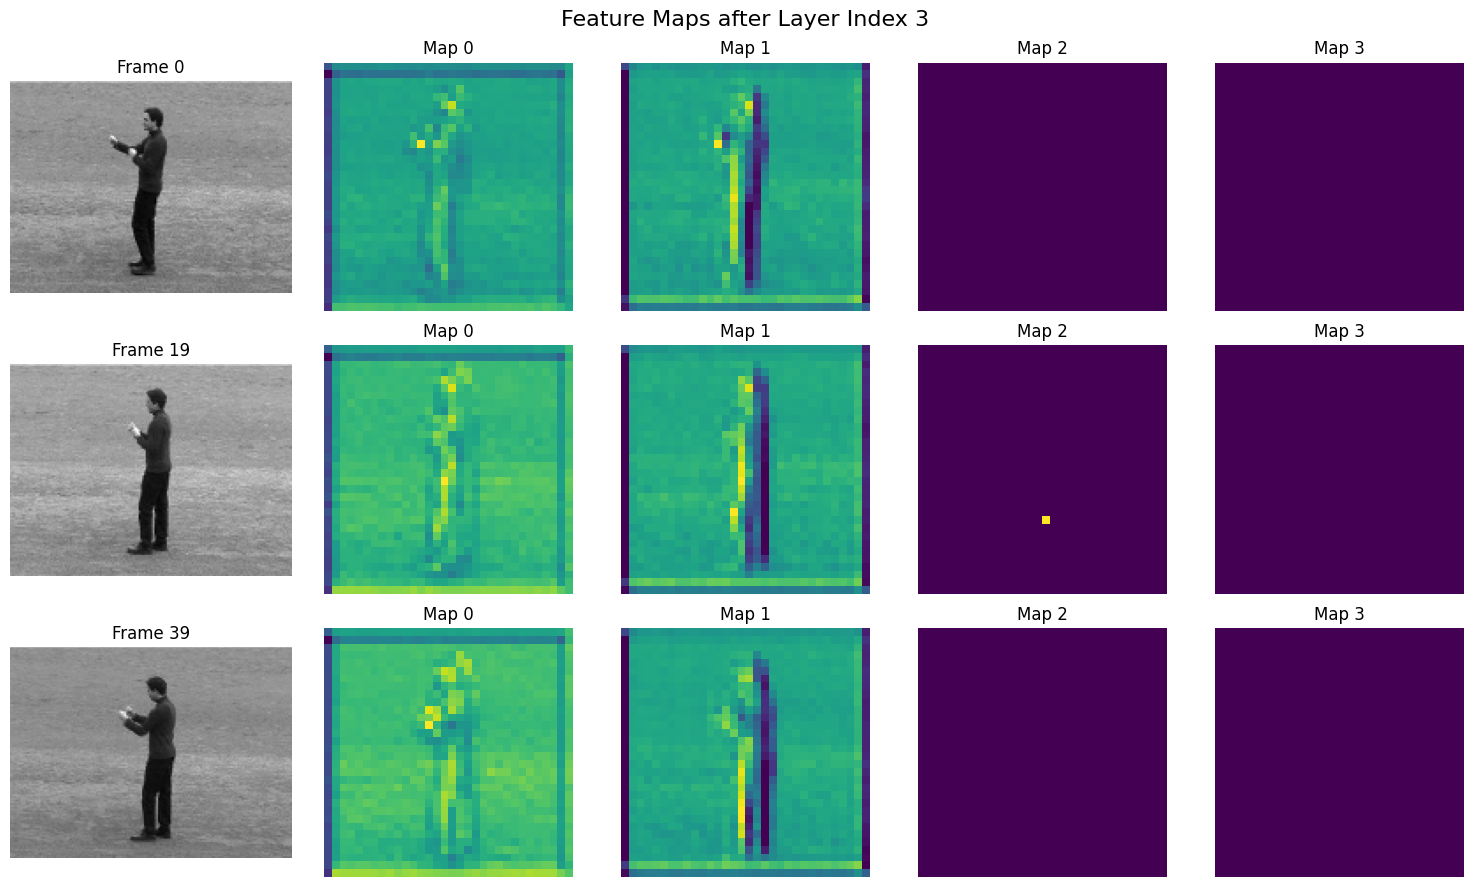

In [ ]:
def visualize_feature_maps(model, video_path, num_frames_to_show=3, layer_idx=0):
    """
    Visualizes the feature maps of a specific layer for a few frames.
    layer_idx 0: First Conv Block
    layer_idx 3: Second Conv Block
    """
    frames = read_video(video_path)
    total = len(frames)
    indices = np.linspace(0, total - 1, NUM_FRAMES, dtype=int)
    sampled = [frames[i] for i in indices]

    # Prepare input
    resized = [cv2.resize(f, (FRAME_SIZE, FRAME_SIZE)).astype(np.float32) / 255.0 for f in sampled]
    video_tensor = torch.tensor(np.stack(resized)).unsqueeze(0).unsqueeze(0).to(device) # (1, 1, 40, 64, 64)

    # We only care about the CNN part
    cnn_part = model.features if hasattr(model, 'features') else model.cnn

    # Get specific layer output
    model.eval()
    with torch.no_grad():
        # Process frame by frame for visualization
        B, C, T, H, W = video_tensor.shape
        input_frames = video_tensor.view(B * T, C, H, W)

        # Extract up to the requested layer
        feature_extractor = nn.Sequential(*list(cnn_part.children())[:layer_idx+2])
        features = feature_extractor(input_frames)

    # Reshape back to (B, T, C_feat, H_feat, W_feat)
    features = features.view(B, T, features.shape[1], features.shape[2], features.shape[3])

    # Plot
    selected_indices = np.linspace(0, NUM_FRAMES - 1, num_frames_to_show, dtype=int)
    fig, axes = plt.subplots(num_frames_to_show, 5, figsize=(15, 3 * num_frames_to_show))

    for i, idx in enumerate(selected_indices):
        # Original frame
        axes[i, 0].imshow(sampled[idx], cmap='gray')
        axes[i, 0].set_title(f"Frame {idx}")
        axes[i, 0].axis('off')

        # First 4 feature maps
        for feat_idx in range(1, 5):
            feat_map = features[0, idx, feat_idx-1].cpu().numpy()
            axes[i, feat_idx].imshow(feat_map, cmap='viridis')
            axes[i, feat_idx].set_title(f"Map {feat_idx-1}")
            axes[i, feat_idx].axis('off')

    plt.suptitle(f"Feature Maps after Layer Index {layer_idx}", fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize the first layer (Initial edge/texture detection)
print("Visualizing Layer 1 (Conv2d 1->32)...")
visualize_feature_maps(cnn_model, "boxing/person01_boxing_d1_uncomp.avi", layer_idx=0)

# Visualize the second block (Higher level features)
print("Visualizing Layer 2 (After second Conv block)...")
visualize_feature_maps(cnn_model, "boxing/person01_boxing_d1_uncomp.avi", layer_idx=3)

### Feature Map Visualization for CNN + LSTM
We will now apply the same visualization technique to the hybrid model to inspect its spatial feature extraction.

Visualizing LSTM Model: Layer 1 (Conv2d 1->32)...


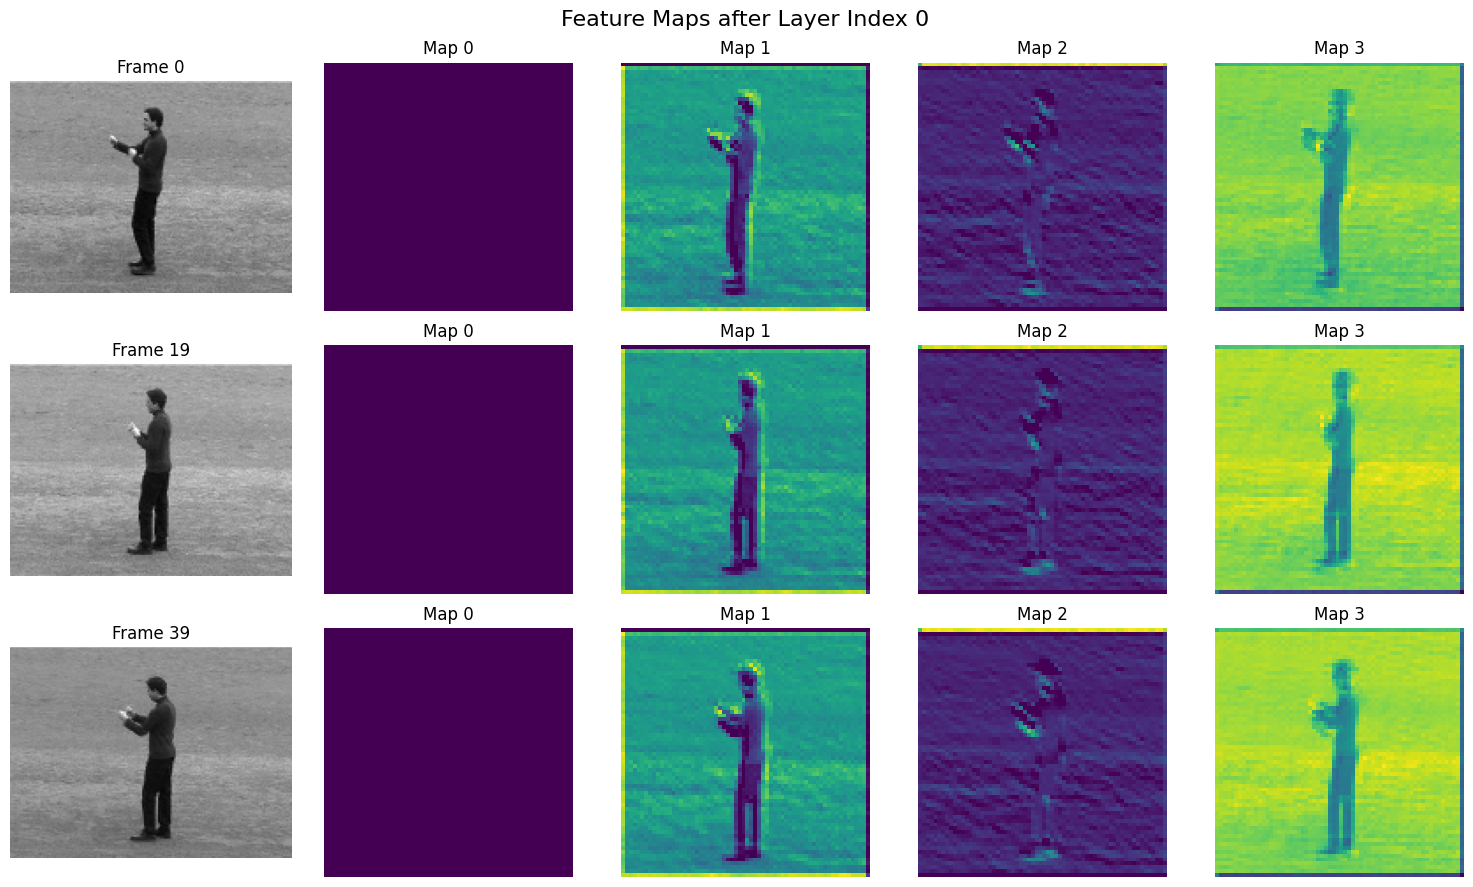

Visualizing LSTM Model: Layer 2 (After second Conv block)...


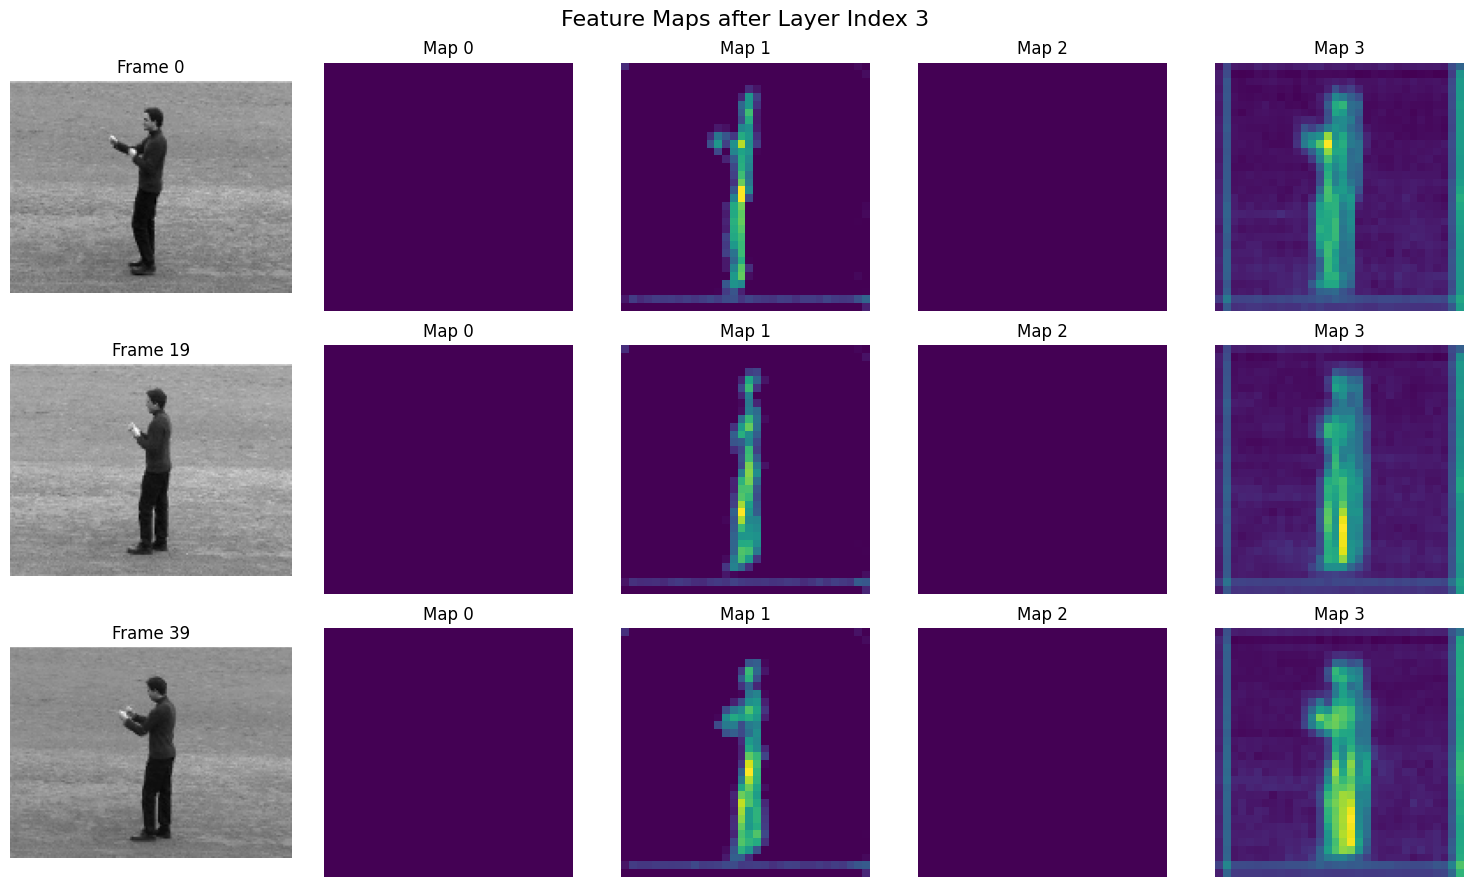

In [ ]:
# Visualize the first layer (Initial edge/texture detection) for LSTM model
print("Visualizing LSTM Model: Layer 1 (Conv2d 1->32)...")
visualize_feature_maps(lstm_model, "boxing/person01_boxing_d1_uncomp.avi", layer_idx=0)

# Visualize the second block (Higher level features) for LSTM model
print("Visualizing LSTM Model: Layer 2 (After second Conv block)...")
visualize_feature_maps(lstm_model, "boxing/person01_boxing_d1_uncomp.avi", layer_idx=3)